## **Graph Cuts and Spectral Clustering: An Algebraic Perspective**

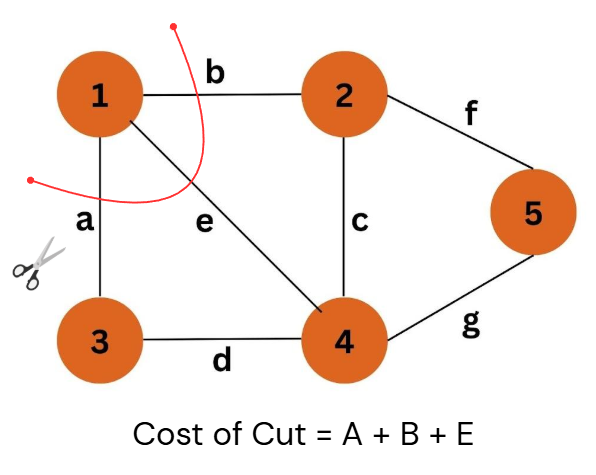

<br>

### **Objective:** <br>
Our goal in the "Graph Cut" problem is to partition a given graph $G$ into two disjoint sets, $A$ and $B$. This partitioning is done by "cutting" the edges that connect these two sets. The cost of this cut is defined as the sum of the weights of the edges that are removed (the edges connecting nodes in set $A$ to nodes in set $B$). We wish to minimize this cost to find the optimal split.

<br>

### **1. Algebraic Representation of the Cut**

Let us define a vector $\mathbf{x}$ where each element $x_i$ indicates which set the node $i$ belongs to. <br>
For a binary partition, we assign:
* $x_i = 1$ if node $i \in A$
* $x_i = -1$ if node $i \in B$

The objective function (the cost of the cut) can be algebraically represented as:

$$J = \frac{1}{4} \sum_{i,j} w_{ij} (x_i - x_j)^2$$

<br>

**Why this formula?**

* If nodes $i$ and $j$ are in the **same** group (both $1$ or both $-1$), then $(x_i - x_j)^2 = 0$. The edge contributes nothing to the cost.

* If nodes $i$ and $j$ are in **different** groups (one is $1$, the other $-1$), then $(x_i - x_j)^2 = (1 - (-1))^2 = 2^2 = 4$.

* The fraction $\frac{1}{4}$ normalizes this value back to $1$, so we are summing exactly the weights $w_{ij}$ of the cut edges.

<br>

### **2. Expanding the Term**

Let's expand the squared term inside the summation:

$$(x_i - x_j)^2 = x_i^2 - 2x_i x_j + x_j^2$$

Substituting this back into our cost function $J$:

$$J = \frac{1}{4} \sum_{i,j} w_{ij} (x_i^2 - 2x_i x_j + x_j^2)$$

We can separate this into three distinct summations:

$$J = \frac{1}{4} \left( \sum_{i,j} w_{ij} x_i^2 - 2 \sum_{i,j} w_{ij} x_i x_j + \sum_{i,j} w_{ij} x_j^2 \right)$$

<br>

### **3. Matrix Formulation: Degree and Adjacency**

To simplify this further, we must understand the definition of the **Degree Matrix ($D$)** and utilize the property of symmetry. <br>

**The First Term ($\sum w_{ij} x_i^2$):** <br>
Since we sum over $j$, note that $x_i$ does not depend on $j$. We can pull it out:
$$\sum_{i} x_i^2 \left( \sum_{j} w_{ij} \right)$$
The term $\sum_{j} w_{ij}$ is simply the **degree** of node $i$ (denoted $d_i$).
Therefore, this term equals $\mathbf{x}^T D \mathbf{x}$.

**The Third Term ($\sum w_{ij} x_j^2$):** <br>
By symmetry (since $i$ and $j$ are just dummy indices in the summation and $w_{ij} = w_{ji}$), this term is identical to the first term.
It also equals $\mathbf{x}^T D \mathbf{x}$.

**The Middle Term ($-2 \sum w_{ij} x_i x_j$):** <br>
This summation is simply the quadratic form of the **Adjacency Matrix ($W$)**.
It equals $-2 \mathbf{x}^T W \mathbf{x}$.

<br>

**Putting it all together:**
$$J = \frac{1}{4} ( \mathbf{x}^T D \mathbf{x} - 2\mathbf{x}^T W \mathbf{x} + \mathbf{x}^T D \mathbf{x} )$$
$$J = \frac{1}{4} ( 2\mathbf{x}^T D \mathbf{x} - 2\mathbf{x}^T W \mathbf{x} )$$
$$J = \frac{1}{2} \mathbf{x}^T (D - W) \mathbf{x}$$

<br>

### **4. The Graph Laplacian ($L$)**

We define the **Laplacian Matrix** as:
$$L = D - W$$

Thus, our minimization objective becomes:
$$\text{Minimize } \mathbf{x}^T L \mathbf{x}$$

<br>

### **5. The Eigenvalue Problem**

Finding the exact discrete solution where $x_i \in \{1, -1\}$ is an NP-Hard problem. To solve this efficiently, we **relax** the constraint. Instead of forcing $x_i$ to be exactly 1 or -1, we allow $x_i$ to be any real number, subject to the magnitude constraint $\mathbf{x}^T \mathbf{x} = 1$ (to prevent the trivial solution of a zero vector).

This transforms the minimization into a **Rayleigh Quotient** problem, which is solved via Lagrange multipliers:
$$L\mathbf{x} = \lambda \mathbf{x}$$

This is a standard **Eigenvalue/Eigenvector problem**.

<br>

**Which Eigenvector do we choose?** <br>
Since we want to **minimize** the function $\mathbf{x}^T L \mathbf{x}$, we look at the eigenvalues $\lambda$:

1.  **Smallest Eigenvalue ($\lambda_0 = 0$):**
    The smallest eigenvalue of a Laplacian is always 0. The corresponding eigenvector is a constant vector (e.g., $[1, 1, ..., 1]$).
    *Interpretation:* This places all nodes in the same partition. This is a valid mathematical minimum, but it does not produce a cut. We discard this.

2.  **Second Smallest Eigenvalue ($\lambda_1$):**
    This is known as the **Fiedler Value**. Its corresponding eigenvector (the **Fiedler Vector**) provides the optimal solution to the relaxed continuous problem. This vector contains real values that "best fit" the cut.

<br>

### **6. Final Algorithm (Spectral Clustering)**

1.  Construct the Laplacian $L = D - W$.
2.  Solve for eigenvalues and eigenvectors.
3.  Select the eigenvector $\mathbf{v}_1$ corresponding to the **second smallest** eigenvalue.
4.  **Thresholding:** Since $\mathbf{v}_1$ contains real numbers, we convert it back to a binary partition by thresholding (usually at 0):
    * If $v_{1,i} \geq 0 \rightarrow$ Assign Node $i$ to Set A.
    * If $v_{1,i} < 0 \rightarrow$ Assign Node $i$ to Set B.

### Demonstration of the Concept

In [1]:
#Necessary Libraries
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#image size
size=50

#image
img=cv.imread("panda.png")
img=cv.cvtColor(img,cv.COLOR_BGR2RGB)
img=cv.resize(img,(size,size))
totalsize=size*size

#translate
pixels = img.reshape(-1, 3)

In [5]:
#similarity Function
def similarity(all,single):
    diff = all - single
    distsq = np.linalg.norm(diff, axis=1) ** 2
    return np.exp(-distsq / 1000)

In [7]:

#memorymatrix
mem=np.zeros((totalsize,totalsize))
for ts in range(totalsize):
    pt=pixels[ts]
    mem[ts,:]=similarity(pixels,pt)

#edge-weights and totalSimilarity
d = np.sum(mem, axis=1)
D = np.diag(d)
L = D - mem

#Solving X.T @ L @ X = 0 ( constrained Lsq )
eigenvalues, eigenvectors = np.linalg.eigh(L)

# index 0 is eigenvalue 0 (constant vector), index 1 is the second smallest
eigenvector = eigenvectors[:, 1]

#-ve values go to one set and +ve goes to another set...
mask = eigenvector > 0
maskreshaped = mask.reshape(size, size)

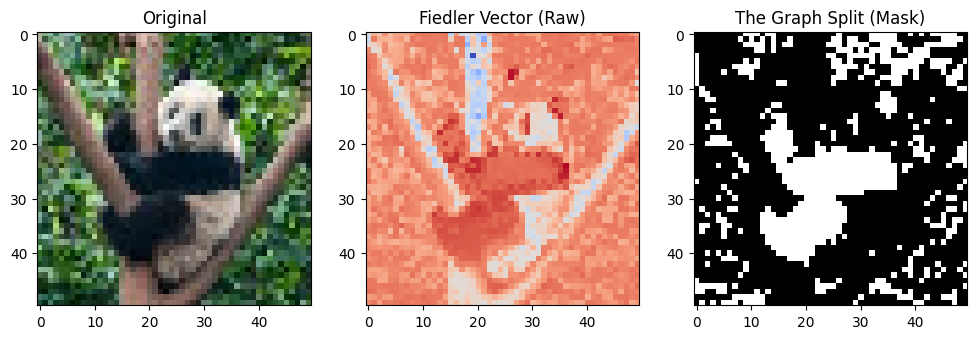

In [8]:
#visualize the image and segments
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(eigenvector.reshape(size, size), cmap='coolwarm')
plt.title("Fiedler Vector (Raw)")

plt.subplot(1, 3, 3)
plt.imshow(maskreshaped, cmap='gray')
plt.title("The Graph Split (Mask)")

plt.show()